In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\namra\Downloads\archive\accepted_2007_to_2018Q4.csv.gz", compression="gzip", low_memory=False)

print(df.shape)
df.head()

(2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# value_counts() counts how many times each unique value appears in a column
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [3]:
# A Python list of column names we want to keep
cols_needed = [
    'loan_amnt',        # original loan amount → used for EAD
    'funded_amnt',       # amount actually funded
    'term',               # loan length (36/60 months)
    'int_rate',           # interest rate
    'installment',        # monthly payment
    'grade', 'sub_grade', # Lending Club's own risk grade (A-G) → good PD feature
    'emp_length',         # employment length → PD feature
    'home_ownership',     # PD feature
    'annual_inc',         # PD feature
    'purpose',            # loan purpose → PD feature
    'dti',                # debt-to-income ratio → strong PD feature
    'loan_status',        # our TARGET (defines default)
    'total_pymnt',        # total amount repaid so far
    'total_rec_prncp',    # principal actually recovered → used for LGD
    'recoveries',         # money recovered after charge-off → used for LGD
    'collection_recovery_fee',  # cost of collecting → used for LGD
    'out_prncp',          # outstanding principal → used for EAD
    'last_pymnt_amnt'
]

# This creates a NEW, smaller DataFrame containing only those columns
# .copy() makes sure it's a fully independent copy, not just a "view" of the original
# (avoids a common pandas warning later when we start editing it)
df_small = df[cols_needed].copy()

print(df_small.shape)
df_small.head()

(2260701, 19)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,loan_status,total_pymnt,total_rec_prncp,recoveries,collection_recovery_fee,out_prncp,last_pymnt_amnt
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,debt_consolidation,5.91,Fully Paid,4421.723917,3600.00,0.0,0.0,0.00,122.67
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,small_business,16.06,Fully Paid,25679.660000,24700.00,0.0,0.0,0.00,926.35
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,home_improvement,10.78,Fully Paid,22705.924294,20000.00,0.0,0.0,0.00,15813.30
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,debt_consolidation,17.06,Current,31464.010000,19102.35,0.0,0.0,15897.65,829.90
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,major_purchase,25.37,Fully Paid,11740.500000,10400.00,0.0,0.0,0.00,10128.96


In [4]:
def map_default(status):
    if status in ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']:
        return 1
    elif status in ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']:
        return 0
    else:
        return None

df_small['default'] = df_small['loan_status'].apply(map_default)

df_model = df_small.dropna(subset=['default']).copy()

print(df_model['default'].value_counts())
print(df_model.shape)

default
0.0    1078739
1.0     269360
Name: count, dtype: int64
(1348099, 20)


In [5]:
# .info() shows every column, how many non-missing values it has, and its data type
df_model.info()


<class 'pandas.DataFrame'>
Index: 1348099 entries, 0 to 2260697
Data columns (total 20 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   loan_amnt                1348099 non-null  float64
 1   funded_amnt              1348099 non-null  float64
 2   term                     1348099 non-null  str    
 3   int_rate                 1348099 non-null  float64
 4   installment              1348099 non-null  float64
 5   grade                    1348099 non-null  str    
 6   sub_grade                1348099 non-null  str    
 7   emp_length               1269549 non-null  str    
 8   home_ownership           1348099 non-null  str    
 9   annual_inc               1348095 non-null  float64
 10  purpose                  1348099 non-null  str    
 11  dti                      1347725 non-null  float64
 12  loan_status              1348099 non-null  str    
 13  total_pymnt              1348099 non-null  float64
 14  to

In [6]:
# --- Fix 'term' ---
# term looks like "36 months" or "60 months" (with a space before "months")
# .str lets us use text-processing operations on a whole column at once
# .str.strip() removes extra spaces from the start/end
# .str.replace(' months', '') removes the word " months", leaving just the number as text
# .astype(int) converts that text number into an actual integer
df_model['term'] = df_model['term'].str.strip().str.replace(' months', '').astype(int)

# --- Fix 'emp_length' ---
# Values look like: '10+ years', '< 1 year', '3 years', 'n/a', or missing (NaN)
# We'll map each text value to a number using a dictionary (a lookup table)
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'n/a': None
}

# .map() looks up each value in df_model['emp_length'] against our dictionary
# and replaces it with the matching number
df_model['emp_length'] = df_model['emp_length'].map(emp_length_map)

# Check it worked
print(df_model['term'].value_counts())
print(df_model['emp_length'].value_counts(dropna=False))

term
36    1023206
60     324893
Name: count, dtype: int64
emp_length
10.0    442679
2.0     122100
0.0     108537
3.0     107868
1.0      88843
5.0      84326
4.0      80763
NaN      78550
6.0      62879
8.0      60811
7.0      59724
9.0      51019
Name: count, dtype: int64


In [7]:
# --- annual_inc and dti: very few missing (4 and 374 out of 1.3M) ---
# Since it's such a tiny fraction, we simply DROP those rows — losing them won't hurt the model at all
df_model = df_model.dropna(subset=['annual_inc', 'dti'])

# --- emp_length: missing for ~78,550 rows (about 6%) — too many to just drop ---
# Instead, we FILL missing values with the median (the "middle" value of the column)
# Why median, not average? Because emp_length is skewed (lots of people at 10+), 
# and median is more robust to that skew than a mean would be
median_emp_length = df_model['emp_length'].median()
print("Median emp_length:", median_emp_length)

df_model['emp_length'] = df_model['emp_length'].fillna(median_emp_length)

# Confirm there are no more missing values in these columns
print(df_model[['annual_inc', 'dti', 'emp_length']].isnull().sum())

Median emp_length: 6.0
annual_inc    0
dti           0
emp_length    0
dtype: int64


In [8]:
# Drop sub_grade — we're keeping the simpler 'grade' column instead
df_model = df_model.drop(columns=['sub_grade'])

# One-hot encoding: turns a category column into multiple 0/1 columns
# e.g., home_ownership = "RENT"/"OWN"/"MORTGAGE" becomes:
#   home_ownership_OWN = 1 or 0
#   home_ownership_RENT = 1 or 0
#   (MORTGAGE has no column — it's the "default" case when both others are 0)

# pd.get_dummies() does this automatically for all the columns we list
df_model = pd.get_dummies(
    df_model,
    columns=['grade', 'home_ownership', 'purpose'],
    drop_first=True   # avoids redundant columns (explained below)
)

print(df_model.shape)
df_model.columns.tolist()   # prints every column name so we can see the new ones

(1347721, 40)


['loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'loan_status',
 'total_pymnt',
 'total_rec_prncp',
 'recoveries',
 'collection_recovery_fee',
 'out_prncp',
 'last_pymnt_amnt',
 'default',
 'grade_B',
 'grade_C',
 'grade_D',
 'grade_E',
 'grade_F',
 'grade_G',
 'home_ownership_MORTGAGE',
 'home_ownership_NONE',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'purpose_credit_card',
 'purpose_debt_consolidation',
 'purpose_educational',
 'purpose_home_improvement',
 'purpose_house',
 'purpose_major_purchase',
 'purpose_medical',
 'purpose_moving',
 'purpose_other',
 'purpose_renewable_energy',
 'purpose_small_business',
 'purpose_vacation',
 'purpose_wedding']

In [9]:
# Columns that are ONLY known after the loan outcome — exclude from PD features
post_origination_cols = ['loan_status', 'total_pymnt', 'total_rec_prncp', 
                          'recoveries', 'collection_recovery_fee', 
                          'out_prncp', 'last_pymnt_amnt', 'default']

# X = our FEATURES (everything the model is allowed to learn from)
# We take all columns EXCEPT the post-origination ones
# .drop(columns=[...]) removes columns; axis isn't needed since we named columns explicitly
X = df_model.drop(columns=post_origination_cols)

# y = our TARGET (what we're trying to predict)
y = df_model['default']

print("X shape:", X.shape)   # should be (1347721, 32) — 40 minus the 8 we removed
print("y shape:", y.shape)
print(X.columns.tolist())

X shape: (1347721, 32)
y shape: (1347721,)
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


In [10]:
from sklearn.model_selection import train_test_split

# train_test_split randomly divides X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% of data held back for testing, 80% used for training
    random_state=42,      # a "seed" — ensures we get the SAME random split every time we run this
    stratify=y             # ensures both train and test sets keep the same 80/20 default ratio
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train shape: (1078176, 32)
Test shape: (269545, 32)
Train default rate: 0.19981060606060605
Test default rate: 0.1998107922610325


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- Step A: Scale the features ---
# Logistic regression is sensitive to features being on very different scales
# e.g., 'loan_amnt' ranges in the thousands, but 'dti' is usually 0-40
# StandardScaler transforms every feature to have mean=0 and standard deviation=1,
# so no single feature dominates just because its numbers happen to be bigger

scaler = StandardScaler()

# fit_transform() on TRAINING data: it learns the scaling rules (mean/std) AND applies them
X_train_scaled = scaler.fit_transform(X_train)

# transform() (NOT fit_transform) on TEST data: it applies the SAME rules learned from training
# We never let the scaler "learn" from test data — that would be a subtle form of leakage
X_test_scaled = scaler.transform(X_test)

# --- Step B: Train the model ---
model = LogisticRegression(max_iter=1000, random_state=42)

# .fit() is where the actual "learning" happens — the model looks at X_train_scaled and y_train
# and finds the best weights (coefficients) for each feature to predict default
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [12]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

# --- Step A: Get predicted probabilities ---
# predict_proba() returns TWO columns: probability of class 0 (no default), probability of class 1 (default)
# [:, 1] selects just the second column — the probability of default, which is what we actually want
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Step B: AUC (Area Under the ROC Curve) ---
# AUC measures how well the model ranks risk: if you pick one defaulter and one non-defaulter at random,
# AUC = the probability the model correctly scores the defaulter as riskier.
# Range: 0.5 = no better than a coin flip, 1.0 = perfect. Real-world PD models usually land around 0.65-0.75.
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

# --- Step C: KS Statistic (Kolmogorov-Smirnov) ---
# This is THE metric credit risk teams care about most. It measures the maximum gap between
# the cumulative % of defaulters vs non-defaulters, as you sort loans from riskiest to safest.
# A higher KS = the model separates good and bad borrowers more cleanly.
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks = max(tpr - fpr)
print("KS Statistic:", ks)

# --- Step D: Gini Coefficient ---
# Gini is just a rescaled version of AUC, and it's the number banks quote most often in credit risk reports
gini = 2 * auc - 1
print("Gini:", gini)

AUC: 0.7019344746671945
KS Statistic: 0.2929991666420497
Gini: 0.403868949334389


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# A model outputs probabilities (e.g., 0.32), but to make a yes/no decision we need a CUTOFF
# 0.5 is the default cutoff: predict "default" if probability > 50%
y_pred_class = (y_pred_proba >= 0.5).astype(int)

# Confusion matrix: a 2x2 table comparing actual vs predicted outcomes
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:")
print(cm)

# classification_report gives precision, recall, f1-score for each class in one summary
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

Confusion Matrix:
[[213611   2076]
 [ 51578   2280]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.99      0.89    215687
         1.0       0.52      0.04      0.08     53858

    accuracy                           0.80    269545
   macro avg       0.66      0.52      0.48    269545
weighted avg       0.75      0.80      0.73    269545



In [14]:
# Step A: Isolate only the loans that actually defaulted
# We go back to df_model (before the train/test split) since we need ALL defaulted loans, not just test ones
defaulted = df_model[df_model['default'] == 1].copy()

print("Number of defaulted loans:", defaulted.shape[0])

# Step B: Calculate EAD (Exposure at Default) — how much was still owed when it defaulted
# funded_amnt = original loan size; total_rec_prncp = principal already paid back BEFORE default
# So funded_amnt - total_rec_prncp = what was still outstanding when it went bad
defaulted['EAD'] = defaulted['funded_amnt'] - defaulted['total_rec_prncp']

# Step C: Calculate net recovery AFTER default
# recoveries = money clawed back after charge-off (e.g., via collections)
# collection_recovery_fee = cost of collecting that money (a cost, so we subtract it)
defaulted['net_recovery'] = defaulted['recoveries'] - defaulted['collection_recovery_fee']

# Step D: Calculate LGD = 1 - (recovery rate)
# If EAD is 0 or negative (rare data quirks), avoid dividing by zero using np.where
import numpy as np
defaulted['LGD'] = 1 - (defaulted['net_recovery'] / defaulted['EAD'])

# Step E: LGD should logically be between 0 and 1 (0% loss to 100% loss)
# Real data sometimes produces small negative or >1 values due to fees/rounding — we CAP (clip) them
defaulted['LGD'] = defaulted['LGD'].clip(lower=0, upper=1)

print(defaulted[['funded_amnt', 'total_rec_prncp', 'EAD', 'net_recovery', 'LGD']].describe())

Number of defaulted loans: 269289
         funded_amnt  total_rec_prncp            EAD   net_recovery  \
count  269289.000000    269289.000000  269289.000000  269289.000000   
mean    15538.083713      4384.126296   11153.957417    1006.316342   
std      8810.514329      4120.704271    7762.922806    1533.284110   
min       500.000000         0.000000       0.000000       0.000000   
25%      9000.000000      1518.720000    4999.270000       0.000000   
50%     14250.000000      3153.650000    9485.630000     492.000000   
75%     20400.000000      5896.030000   15563.480000    1435.361400   
max     40000.000000     39989.790000   40000.000000   39397.805600   

                 LGD  
count  269271.000000  
mean        0.908672  
std         0.111026  
min         0.000000  
25%         0.880608  
50%         0.915467  
75%         1.000000  
max         1.000000  


In [15]:
# These 18 rows have EAD=0 (nothing was actually outstanding at "default" — likely a data quirk)
# Since it's a tiny number, we just drop them
defaulted = defaulted.dropna(subset=['LGD'])
print(defaulted.shape)


(269271, 43)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# --- Step A: Build features for the LGD model ---
# We reuse the same kind of loan-characteristic features as PD
# (excluding post-default columns like recoveries — those would leak the answer, since LGD IS derived from them)
lgd_features = ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
                 'emp_length', 'annual_inc', 'dti',
                 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G',
                 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER',
                 'home_ownership_OWN', 'home_ownership_RENT',
                 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational',
                 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
                 'purpose_medical', 'purpose_moving', 'purpose_other',
                 'purpose_renewable_energy', 'purpose_small_business',
                 'purpose_vacation', 'purpose_wedding']

X_lgd = defaulted[lgd_features]
y_lgd = defaulted['LGD']

# --- Step B: Train/test split (same logic as before, no stratify needed since this isn't classification) ---
X_lgd_train, X_lgd_test, y_lgd_train, y_lgd_test = train_test_split(
    X_lgd, y_lgd, test_size=0.2, random_state=42
)

# --- Step C: Scale features (same reasoning as PD model) ---
lgd_scaler = StandardScaler()
X_lgd_train_scaled = lgd_scaler.fit_transform(X_lgd_train)
X_lgd_test_scaled = lgd_scaler.transform(X_lgd_test)

# --- Step D: Train a Linear Regression model ---
lgd_model = LinearRegression()
lgd_model.fit(X_lgd_train_scaled, y_lgd_train)

# --- Step E: Evaluate ---
y_lgd_pred = lgd_model.predict(X_lgd_test_scaled)

mae = mean_absolute_error(y_lgd_test, y_lgd_pred)
r2 = r2_score(y_lgd_test, y_lgd_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 0.0736299370458504
R²: 0.0045060308133682


In [17]:
# Simple, robust alternative: average LGD by grade
lgd_by_grade = defaulted.groupby(['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G'])['LGD'].mean()
# (This is a rough grouping since grade is one-hot encoded — a cleaner version below)

# Cleaner: recreate a single 'grade' label just for this summary
grade_cols = ['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G']
defaulted['grade_label'] = 'A'  # default/baseline since grade_A was dropped in one-hot encoding
for col in grade_cols:
    defaulted.loc[defaulted[col] == 1, 'grade_label'] = col.replace('grade_', '')

avg_lgd_by_grade = defaulted.groupby('grade_label')['LGD'].mean().sort_index()
print(avg_lgd_by_grade)


grade_label
A    0.911408
B    0.909826
C    0.909350
D    0.909047
E    0.906272
F    0.903526
G    0.904606
Name: LGD, dtype: float64


In [18]:
# These are the extra columns we want, pulled from the ORIGINAL full dataset (df), not df_small
extra_cols = ['revol_util', 'total_acc', 'open_acc', 'delinq_2yrs', 
              'pub_rec', 'mths_since_last_delinq', 'verification_status']

# Pull just these columns from df
df_extra = df[extra_cols].copy()

# Since 'defaulted' still has the SAME row index as the original df (we never reset it),
# we can join these new columns onto 'defaulted' by matching index automatically
defaulted = defaulted.join(df_extra)

print(defaulted.shape)
defaulted[extra_cols].info()

(269271, 51)
<class 'pandas.DataFrame'>
Index: 269271 entries, 13 to 2260697
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   revol_util              269085 non-null  float64
 1   total_acc               269268 non-null  float64
 2   open_acc                269268 non-null  float64
 3   delinq_2yrs             269268 non-null  float64
 4   pub_rec                 269268 non-null  float64
 5   mths_since_last_delinq  138266 non-null  float64
 6   verification_status     269271 non-null  str    
dtypes: float64(6), str(1)
memory usage: 19.5 MB


In [19]:
# --- mths_since_last_delinq: create an indicator flag BEFORE filling ---
# 1 = has never been delinquent (this is what missing means here)
# 0 = has a real value (they were delinquent at some point)
defaulted['never_delinquent'] = defaulted['mths_since_last_delinq'].isnull().astype(int)

# Now fill the missing values with a large number (e.g., 999) to represent
# "so long ago / never, that it doesn't meaningfully affect risk" — a common trick,
# since the model will separately know via 'never_delinquent' that this is a special case
defaulted['mths_since_last_delinq'] = defaulted['mths_since_last_delinq'].fillna(999)

# --- The rest: tiny missingness (~200 rows out of 269k), safe to just drop ---
defaulted = defaulted.dropna(subset=['revol_util', 'total_acc', 'open_acc', 'delinq_2yrs', 'pub_rec'])

# --- One-hot encode verification_status (it's a category: Verified / Source Verified / Not Verified) ---
defaulted = pd.get_dummies(defaulted, columns=['verification_status'], drop_first=True)

print(defaulted.shape)
defaulted.filter(like='verification').columns.tolist()  # confirm new columns exist

(269085, 53)


['verification_status_Source Verified', 'verification_status_Verified']

In [20]:
from sklearn.ensemble import RandomForestRegressor

# --- Step A: Build the expanded feature list ---
# Original loan-origination features + new bureau-style features
lgd_features_v2 = lgd_features + [
    'revol_util', 'total_acc', 'open_acc', 'delinq_2yrs', 'pub_rec',
    'mths_since_last_delinq', 'never_delinquent',
    'verification_status_Source Verified', 'verification_status_Verified'
]

X_lgd2 = defaulted[lgd_features_v2]
y_lgd2 = defaulted['LGD']

# --- Step B: Train/test split ---
X_lgd2_train, X_lgd2_test, y_lgd2_train, y_lgd2_test = train_test_split(
    X_lgd2, y_lgd2, test_size=0.2, random_state=42
)

# NOTE: Random Forest does NOT need feature scaling — it splits data based on thresholds
# (like "is revol_util > 70?"), not distances or magnitudes, so StandardScaler isn't needed here.
# This is a genuine advantage of tree-based models over linear/logistic ones.

# --- Step C: Train Random Forest ---
rf_lgd_model = RandomForestRegressor(
    n_estimators=200,      # number of individual decision trees to build and average together
    max_depth=8,            # limits how deep each tree can grow, to avoid overfitting
    random_state=42,
    n_jobs=-1                # use all available CPU cores to train faster
)

rf_lgd_model.fit(X_lgd2_train, y_lgd2_train)

# --- Step D: Evaluate ---
y_lgd2_pred = rf_lgd_model.predict(X_lgd2_test)

mae2 = mean_absolute_error(y_lgd2_test, y_lgd2_pred)
r2_2 = r2_score(y_lgd2_test, y_lgd2_pred)

print("New MAE:", mae2)
print("New R²:", r2_2)
print("\n--- Comparison ---")
print("Old Linear Regression: MAE=0.0736, R²=0.0045")
print(f"New Random Forest:     MAE={mae2:.4f}, R²={r2_2:.4f}")

New MAE: 0.07327695776404737
New R²: 0.009374418398279127

--- Comparison ---
Old Linear Regression: MAE=0.0736, R²=0.0045
New Random Forest:     MAE=0.0733, R²=0.0094


In [21]:
import pandas as pd

# feature_importances_ tells us how much each feature contributed to the Random Forest's decisions
importances = pd.Series(rf_lgd_model.feature_importances_, index=lgd_features_v2)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

annual_inc                0.130737
revol_util                0.126236
total_acc                 0.098312
int_rate                  0.098056
dti                       0.084549
installment               0.067607
loan_amnt                 0.043089
mths_since_last_delinq    0.041575
open_acc                  0.040985
funded_amnt               0.032267
dtype: float64


In [22]:
# --- Step A: Predict PD for every loan using our trained PD model ---
X_all = df_model[X.columns]                     # same 32 PD features, same order
X_all_scaled = scaler.transform(X_all)           # reuse the SAME fitted scaler — never re-fit
df_model['PD'] = model.predict_proba(X_all_scaled)[:, 1]

# --- Step B: Assign LGD using our segment-average-by-grade lookup ---
grade_cols = ['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G']
df_model['grade_label'] = 'A'
for col in grade_cols:
    df_model.loc[df_model[col] == 1, 'grade_label'] = col.replace('grade_', '')

df_model['LGD'] = df_model['grade_label'].map(avg_lgd_by_grade)

# --- Step C: EAD = current outstanding principal ---
df_model['EAD'] = df_model['out_prncp']

# --- Step D: ECL per loan ---
df_model['ECL'] = df_model['PD'] * df_model['LGD'] * df_model['EAD']

# --- Step E: Portfolio-level summary ---
total_ead = df_model['EAD'].sum()
total_ecl = df_model['ECL'].sum()
coverage_ratio = total_ecl / total_ead

print(f"Total Outstanding Exposure (EAD): ${total_ead:,.0f}")
print(f"Total Expected Credit Loss (ECL): ${total_ecl:,.0f}")
print(f"Portfolio Coverage Ratio (ECL/EAD): {coverage_ratio:.2%}")

df_model[['loan_amnt','grade_label','PD','LGD','EAD','ECL']].head(10)

Total Outstanding Exposure (EAD): $382,933
Total Expected Credit Loss (ECL): $107,772
Portfolio Coverage Ratio (ECL/EAD): 28.14%


,loan_amnt,grade_label,PD,LGD,EAD,ECL
0,3600.0,C,0.140970,0.909350,0.0,0.0
1,24700.0,C,0.231523,0.909350,0.0,0.0
2,20000.0,B,0.162191,0.909826,0.0,0.0
4,10400.0,F,0.396641,0.903526,0.0,0.0
5,11950.0,C,0.222911,0.909350,0.0,0.0
6,20000.0,B,0.085863,0.909826,0.0,0.0
7,20000.0,B,0.103667,0.909826,0.0,0.0
8,10000.0,A,0.065643,0.911408,0.0,0.0
9,8000.0,B,0.129292,0.909826,0.0,0.0
12,1400.0,C,0.175740,0.909350,0.0,0.0


In [23]:
# Step A: Get the loans that are currently active (this is our REAL portfolio to assess)
current_loans = df[df['loan_status'] == 'Current'].copy()

print("Number of current/active loans:", current_loans.shape[0])
print("Total outstanding EAD in live book:", current_loans['out_prncp'].sum())


Number of current/active loans: 878317
Total outstanding EAD in live book: 9125761309.86


In [24]:
# --- Step A: Select the same columns we need ---
current_small = current_loans[cols_needed].copy()

# --- Step B: Same term/emp_length fixes as before ---
current_small['term'] = current_small['term'].str.strip().str.replace(' months', '').astype(int)
current_small['emp_length'] = current_small['emp_length'].map(emp_length_map)
current_small['emp_length'] = current_small['emp_length'].fillna(median_emp_length)

# --- Step C: Drop rows missing annual_inc/dti (same reasoning as before, tiny amount) ---
current_small = current_small.dropna(subset=['annual_inc', 'dti'])

# --- Step D: Same one-hot encoding ---
current_small = pd.get_dummies(
    current_small,
    columns=['grade', 'home_ownership', 'purpose'],
    drop_first=True
)

print(current_small.shape)


(877018, 39)


In [25]:
# reindex() forces current_small to have EXACTLY the same columns as X (our training features)
# columns present in X but missing here get filled with 0 (meaning "this category didn't occur")
# any extra columns not in X get dropped automatically
X_current = current_small.reindex(columns=X.columns, fill_value=0)

print(X_current.shape)   # should be (some_number, 32) — matching X's 32 columns exactly

(877018, 32)


In [26]:
# --- Step A: Predict PD using our trained PD model ---
X_current_scaled = scaler.transform(X_current)   # reuse the SAME fitted scaler from training
current_small['PD'] = model.predict_proba(X_current_scaled)[:, 1]

# --- Step B: Assign LGD via segment-average-by-grade lookup ---
grade_cols = ['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G']
current_small['grade_label'] = 'A'
for col in grade_cols:
    current_small.loc[current_small[col] == 1, 'grade_label'] = col.replace('grade_', '')

current_small['LGD'] = current_small['grade_label'].map(avg_lgd_by_grade)

# --- Step C: EAD = current outstanding principal ---
current_small['EAD'] = current_small['out_prncp']

# --- Step D: ECL per loan ---
current_small['ECL'] = current_small['PD'] * current_small['LGD'] * current_small['EAD']

# --- Step E: Portfolio-level summary ---
total_ead = current_small['EAD'].sum()
total_ecl = current_small['ECL'].sum()
coverage_ratio = total_ecl / total_ead

print(f"Total Outstanding Exposure (EAD): ${total_ead:,.0f}")
print(f"Total Expected Credit Loss (ECL): ${total_ecl:,.0f}")
print(f"Portfolio Coverage Ratio (ECL/EAD): {coverage_ratio:.2%}")

# --- Bonus: break it down by grade, which is exactly how a real risk report would present it ---
ecl_by_grade = current_small.groupby('grade_label').agg(
    Exposure=('EAD','sum'),
    ECL=('ECL','sum'),
    Avg_PD=('PD','mean'),
    Avg_LGD=('LGD','mean')
)
ecl_by_grade['Coverage_Ratio'] = ecl_by_grade['ECL'] / ecl_by_grade['Exposure']
print(ecl_by_grade)

Total Outstanding Exposure (EAD): $9,105,602,016
Total Expected Credit Loss (ECL): $1,775,860,083
Portfolio Coverage Ratio (ECL/EAD): 19.50%
                 Exposure           ECL    Avg_PD   Avg_LGD  Coverage_Ratio
grade_label                                                                
A            1.976313e+09  1.202154e+08  0.064415  0.911408        0.060828
B            2.596187e+09  3.677875e+08  0.145575  0.909826        0.141664
C            2.707443e+09  6.405728e+08  0.245325  0.909350        0.236597
D            1.273660e+09  4.122311e+08  0.335393  0.909047        0.323659
E            4.127083e+08  1.675835e+08  0.421005  0.906272        0.406058
F            1.052425e+08  5.012399e+07  0.502369  0.903526        0.476271
G            3.404856e+07  1.734566e+07  0.539747  0.904606        0.509439


In [27]:
# Convert lifetime PD → 12-month PD, using each loan's own term (36 or 60 months)
current_small['PD_12m'] = 1 - (1 - current_small['PD']) ** (12 / current_small['term'])

# Recalculate ECL using the 12-month PD instead of lifetime PD
current_small['ECL_12m'] = current_small['PD_12m'] * current_small['LGD'] * current_small['EAD']

# New portfolio summary
total_ead = current_small['EAD'].sum()
total_ecl_12m = current_small['ECL_12m'].sum()
coverage_ratio_12m = total_ecl_12m / total_ead

print(f"Total Outstanding Exposure (EAD): ${total_ead:,.0f}")
print(f"Total 12-Month ECL (Stage 1): ${total_ecl_12m:,.0f}")
print(f"Portfolio Coverage Ratio (12-month): {coverage_ratio_12m:.2%}")

# Compare old (lifetime, mislabeled) vs new (proper 12-month) side by side
print("\n--- Comparison ---")
print(f"Old (lifetime PD applied uniformly): 19.50%")
print(f"New (12-month PD, Stage 1 basis):    {coverage_ratio_12m:.2%}")

# By-grade breakdown with the corrected number
ecl_by_grade_12m = current_small.groupby('grade_label').agg(
    Exposure=('EAD','sum'),
    ECL_12m=('ECL_12m','sum'),
    Avg_PD_12m=('PD_12m','mean')
)
ecl_by_grade_12m['Coverage_Ratio'] = ecl_by_grade_12m['ECL_12m'] / ecl_by_grade_12m['Exposure']
print(ecl_by_grade_12m)

Total Outstanding Exposure (EAD): $9,105,602,016
Total 12-Month ECL (Stage 1): $495,592,186
Portfolio Coverage Ratio (12-month): 5.44%

--- Comparison ---
Old (lifetime PD applied uniformly): 19.50%
New (12-month PD, Stage 1 basis):    5.44%
                 Exposure       ECL_12m  Avg_PD_12m  Coverage_Ratio
grade_label                                                        
A            1.976313e+09  3.813791e+07    0.021041        0.019298
B            2.596187e+09  1.026650e+08    0.043985        0.039545
C            2.707443e+09  1.736388e+08    0.071413        0.064134
D            1.273660e+09  1.149252e+08    0.098890        0.090232
E            4.127083e+08  4.749111e+07    0.123390        0.115072
F            1.052425e+08  1.377054e+07    0.140287        0.130846
G            3.404856e+07  4.963637e+06    0.156044        0.145781


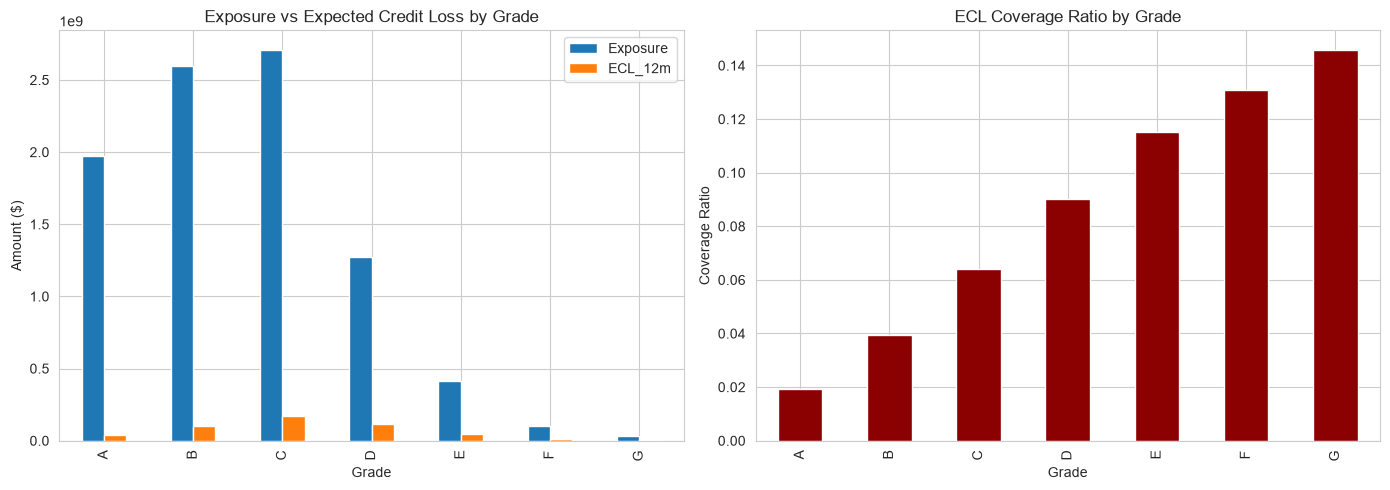

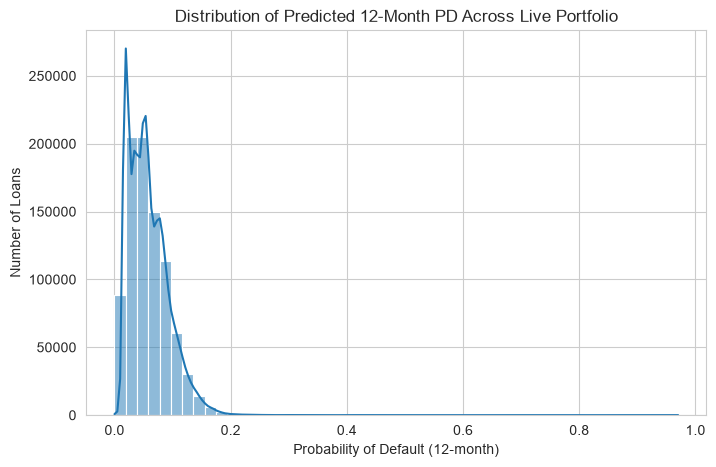

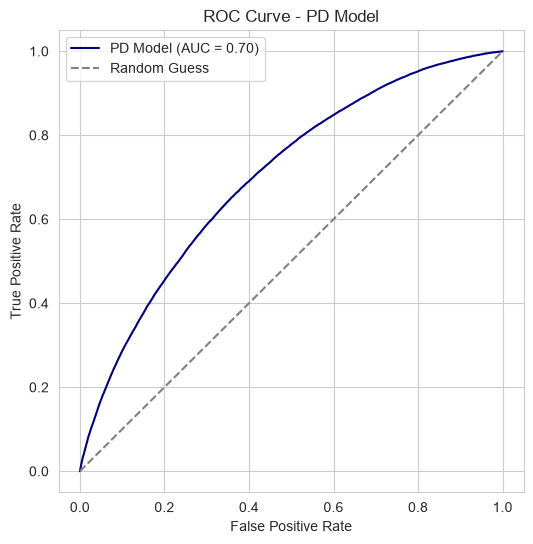

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our charts
sns.set_style('whitegrid')

# --- Chart 1: ECL by Grade (bar chart) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 charts side by side

# Left chart: Exposure vs ECL by grade
ecl_by_grade_12m[['Exposure', 'ECL_12m']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Exposure vs Expected Credit Loss by Grade')
axes[0].set_ylabel('Amount ($)')
axes[0].set_xlabel('Grade')

# Right chart: Coverage ratio by grade
ecl_by_grade_12m['Coverage_Ratio'].plot(kind='bar', ax=axes[1], color='darkred')
axes[1].set_title('ECL Coverage Ratio by Grade')
axes[1].set_ylabel('Coverage Ratio')
axes[1].set_xlabel('Grade')

plt.tight_layout()  # prevents titles/labels from overlapping
plt.show()

# --- Chart 2: PD distribution ---
plt.figure(figsize=(8, 5))
sns.histplot(current_small['PD_12m'], bins=50, kde=True)
plt.title('Distribution of Predicted 12-Month PD Across Live Portfolio')
plt.xlabel('Probability of Default (12-month)')
plt.ylabel('Number of Loans')
plt.show()

# --- Chart 3: ROC Curve for the PD model (shows model quality visually) ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'PD Model (AUC = {auc:.2f})', color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PD Model')
plt.legend()
plt.show()

In [29]:
import numpy as np
import pandas as pd

# Combine training features and target into one table for this analysis
woe_data = X_train.copy()
woe_data['default'] = y_train

# Step A: Bin dti into 5 equal-width ranges
woe_data['dti_bin'] = pd.cut(woe_data['dti'], bins=5)

# Step B: Count good/bad per bin
grouped = woe_data.groupby('dti_bin')['default'].agg(['count', 'sum'])
grouped.columns = ['total', 'bad']
grouped['good'] = grouped['total'] - grouped['bad']

# Step C: % of all goods/bads in each bin
total_good = grouped['good'].sum()
total_bad = grouped['bad'].sum()
grouped['good_pct'] = grouped['good'] / total_good
grouped['bad_pct'] = grouped['bad'] / total_bad

# Step D: WOE
grouped['WOE'] = np.log(grouped['good_pct'] / grouped['bad_pct'])

# Step E: IV per bin, summed
grouped['IV_bin'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['WOE']
total_IV = grouped['IV_bin'].sum()

print(grouped)
print("\nTotal IV for dti:", total_IV)

                  total       bad      good  good_pct   bad_pct       WOE  \
dti_bin                                                                     
(-2.0, 199.0]   1078003  215392.0  862611.0  0.999845  0.999819  0.000026   
(199.0, 399.0]      101      23.0      78.0  0.000090  0.000107 -0.166264   
(399.0, 599.0]       21       5.0      16.0  0.000019  0.000023 -0.224328   
(599.0, 799.0]       14       3.0      11.0  0.000013  0.000014 -0.088196   
(799.0, 999.0]       37       8.0      29.0  0.000034  0.000037 -0.099624   

                      IV_bin  
dti_bin                       
(-2.0, 199.0]   6.613335e-10  
(199.0, 399.0]  2.719017e-06  
(399.0, 599.0]  1.046226e-06  
(599.0, 799.0]  1.036801e-07  
(799.0, 999.0]  3.507987e-07  

Total IV for dti: 4.220383018643841e-06


In [30]:
# Same logic as before, but using qcut instead of cut
woe_data['dti_bin'] = pd.qcut(woe_data['dti'], q=5, duplicates='drop')

grouped = woe_data.groupby('dti_bin')['default'].agg(['count', 'sum'])
grouped.columns = ['total', 'bad']
grouped['good'] = grouped['total'] - grouped['bad']

total_good = grouped['good'].sum()
total_bad = grouped['bad'].sum()
grouped['good_pct'] = grouped['good'] / total_good
grouped['bad_pct'] = grouped['bad'] / total_bad

grouped['WOE'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
grouped['IV_bin'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['WOE']
total_IV = grouped['IV_bin'].sum()

print(grouped)
print("\nTotal IV for dti:", total_IV)

                  total      bad      good  good_pct   bad_pct       WOE  \
dti_bin                                                                    
(-1.001, 10.48]  215705  32410.0  183295.0  0.212456  0.150443  0.345151   
(10.48, 15.32]   215875  36177.0  179698.0  0.208286  0.167928  0.215376   
(15.32, 19.98]   215629  41230.0  174399.0  0.202144  0.191384  0.054701   
(19.98, 25.68]   215455  47252.0  168203.0  0.194963  0.219337 -0.117802   
(25.68, 999.0]   215512  58362.0  157150.0  0.182151  0.270908 -0.396943   

                   IV_bin  
dti_bin                    
(-1.001, 10.48]  0.021404  
(10.48, 15.32]   0.008692  
(15.32, 19.98]   0.000589  
(19.98, 25.68]   0.002871  
(25.68, 999.0]   0.035231  

Total IV for dti: 0.06878735645836714


In [31]:
# Check how common these extreme dti values actually are
print(woe_data['dti'].describe())
print("\nNumber of loans with dti > 100:", (woe_data['dti'] > 100).sum())

count    1.078176e+06
mean     1.828027e+01
std      1.127060e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.405000e+01
max      9.990000e+02
Name: dti, dtype: float64

Number of loans with dti > 100: 430


In [32]:
# Cap dti at a realistic range: 0 to 60 (values above this are almost certainly data errors)
# This affects woe_data here, but we should apply the same fix back to X_train/X_test/df_model too
woe_data['dti'] = woe_data['dti'].clip(lower=0, upper=60)

# Re-run the qcut binning with the cleaned dti
woe_data['dti_bin'] = pd.qcut(woe_data['dti'], q=5, duplicates='drop')

grouped = woe_data.groupby('dti_bin')['default'].agg(['count', 'sum'])
grouped.columns = ['total', 'bad']
grouped['good'] = grouped['total'] - grouped['bad']

total_good = grouped['good'].sum()
total_bad = grouped['bad'].sum()
grouped['good_pct'] = grouped['good'] / total_good
grouped['bad_pct'] = grouped['bad'] / total_bad

grouped['WOE'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
grouped['IV_bin'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['WOE']
total_IV = grouped['IV_bin'].sum()

print(grouped)
print("\nTotal IV for dti (cleaned):", total_IV)

                  total      bad      good  good_pct   bad_pct       WOE  \
dti_bin                                                                    
(-0.001, 10.48]  215705  32410.0  183295.0  0.212456  0.150443  0.345151   
(10.48, 15.32]   215875  36177.0  179698.0  0.208286  0.167928  0.215376   
(15.32, 19.98]   215629  41230.0  174399.0  0.202144  0.191384  0.054701   
(19.98, 25.68]   215455  47252.0  168203.0  0.194963  0.219337 -0.117802   
(25.68, 60.0]    215512  58362.0  157150.0  0.182151  0.270908 -0.396943   

                   IV_bin  
dti_bin                    
(-0.001, 10.48]  0.021404  
(10.48, 15.32]   0.008692  
(15.32, 19.98]   0.000589  
(19.98, 25.68]   0.002871  
(25.68, 60.0]    0.035231  

Total IV for dti (cleaned): 0.06878735645836714


In [33]:
# Apply the dti cap permanently to all datasets that use it
X_train['dti'] = X_train['dti'].clip(lower=0, upper=60)
X_test['dti'] = X_test['dti'].clip(lower=0, upper=60)
df_model['dti'] = df_model['dti'].clip(lower=0, upper=60)

print("dti capped in X_train, X_test, df_model")
print(X_train['dti'].describe())


dti capped in X_train, X_test, df_model
count    1.078176e+06
mean     1.818345e+01
std      8.643548e+00
min      0.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.405000e+01
max      6.000000e+01
Name: dti, dtype: float64


In [34]:
import numpy as np
import pandas as pd

def calculate_woe_iv(df, feature, target, bins=5):
    """
    Bins a numeric feature using QUANTILES (equal population per bin, robust to outliers),
    then calculates WOE and IV per bin.
    """
    data = df[[feature, target]].copy()
    
    # Quantile-based binning instead of equal-width
    data[f'{feature}_bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    
    grouped = data.groupby(f'{feature}_bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    # Small epsilon avoids log(0) if any bin has zero goods or bads
    epsilon = 0.5
    grouped['good_pct'] = (grouped['good'] + epsilon) / (total_good + epsilon)
    grouped['bad_pct'] = (grouped['bad'] + epsilon) / (total_bad + epsilon)
    
    grouped['WOE'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['IV_bin'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['WOE']
    
    total_IV = grouped['IV_bin'].sum()
    
    return grouped, total_IV

# Numeric features to evaluate (categorical 0/1 columns like grade_B are handled separately later)
numeric_features = ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
                     'emp_length', 'annual_inc', 'dti']

woe_data = X_train.copy()
woe_data['default'] = y_train

iv_summary = {}
woe_tables = {}

for feature in numeric_features:
    grouped, total_iv = calculate_woe_iv(woe_data, feature, 'default', bins=5)
    iv_summary[feature] = total_iv
    woe_tables[feature] = grouped

iv_df = pd.Series(iv_summary).sort_values(ascending=False)
print(iv_df)


int_rate       0.422008
dti            0.068786
funded_amnt    0.033748
loan_amnt      0.033710
installment    0.028586
annual_inc     0.028085
emp_length     0.004198
term           0.000000
dtype: float64


In [35]:
# grade is already one-hot encoded (grade_B, grade_C, etc.) — reconstruct a single label to bin it properly
grade_cols = ['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G']
woe_data['grade_label'] = 'A'
for col in grade_cols:
    woe_data.loc[woe_data[col] == 1, 'grade_label'] = col.replace('grade_', '')

# For a CATEGORICAL feature, we group by its natural categories directly — no qcut needed
grouped_grade = woe_data.groupby('grade_label')['default'].agg(['count', 'sum'])
grouped_grade.columns = ['total', 'bad']
grouped_grade['good'] = grouped_grade['total'] - grouped_grade['bad']

total_good = grouped_grade['good'].sum()
total_bad = grouped_grade['bad'].sum()
grouped_grade['good_pct'] = grouped_grade['good'] / total_good
grouped_grade['bad_pct'] = grouped_grade['bad'] / total_bad
grouped_grade['WOE'] = np.log(grouped_grade['good_pct'] / grouped_grade['bad_pct'])
grouped_grade['IV_bin'] = (grouped_grade['good_pct'] - grouped_grade['bad_pct']) * grouped_grade['WOE']

total_IV_grade = grouped_grade['IV_bin'].sum()
print(grouped_grade.sort_index())
print("\nTotal IV for grade:", total_IV_grade)

              total      bad      good  good_pct   bad_pct       WOE    IV_bin
grade_label                                                                   
A            188114  11419.0  176695.0  0.204806  0.053005  1.351668  0.205183
B            314560  42003.0  272557.0  0.315918  0.194972  0.482628  0.058372
C            305476  68528.0  236948.0  0.274644  0.318097 -0.146880  0.006382
D            161270  48919.0  112351.0  0.130225  0.227075 -0.556016  0.053850
E             75352  29091.0   46261.0  0.053621  0.135036 -0.923608  0.075196
F             25860  11723.0   14137.0  0.016386  0.054416 -1.200236  0.045645
G              7544   3748.0    3796.0  0.004400  0.017398 -1.374753  0.017869

Total IV for grade: 0.4624984935383362


In [36]:
# Re-run with 10 bins instead of 5, to see if finer binning reveals more structure
grouped_loan, iv_loan = calculate_woe_iv(woe_data, 'loan_amnt', 'default', bins=10)
print(grouped_loan)
print("\nTotal IV for loan_amnt (10 bins):", iv_loan)

                     total      bad      good  good_pct   bad_pct       WOE  \
loan_amnt_bin                                                                 
(499.999, 5000.0]   146754  23150.0  123604.0  0.143269  0.107461  0.287594   
(5000.0, 6500.0]     71231  11229.0   60002.0  0.069548  0.052126  0.288365   
(6500.0, 8600.0]    105901  17948.0   87953.0  0.101946  0.083314  0.201825   
(8600.0, 10000.0]   122239  22440.0   99799.0  0.115677  0.104165  0.104819   
(10000.0, 12000.0]  102959  21230.0   81729.0  0.094732  0.098549 -0.039501   
(12000.0, 15000.0]  124230  26060.0   98170.0  0.113788  0.120969 -0.061192   
(15000.0, 18000.0]   91823  20930.0   70893.0  0.082172  0.097156 -0.167505   
(18000.0, 21000.0]   99964  22736.0   77228.0  0.089515  0.105539 -0.164680   
(21000.0, 28000.0]  117781  26387.0   91394.0  0.105934  0.122487 -0.145182   
(28000.0, 40000.0]   95294  23321.0   71973.0  0.083424  0.108255 -0.260554   

                      IV_bin  
loan_amnt_bin       

In [37]:
# Quick sanity check for outliers, same lesson as dti
print(woe_data['annual_inc'].describe())

count    1.078176e+06
mean     7.625596e+04
std      7.033643e+04
min      1.600000e+01
25%      4.586400e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64


In [38]:
grouped_income, iv_income = calculate_woe_iv(woe_data, 'annual_inc', 'default', bins=5)
print(grouped_income)
print("\nTotal IV for annual_inc:", iv_income)



                         total      bad      good  good_pct   bad_pct  \
annual_inc_bin                                                          
(15.999, 42000.0]       220174  51828.0  168346.0  0.195129  0.240580   
(42000.0, 57000.0]      215335  46619.0  168716.0  0.195558  0.216401   
(57000.0, 74000.0]      212658  43170.0  169488.0  0.196452  0.200391   
(74000.0, 100000.0]     229439  42221.0  187218.0  0.217003  0.195986   
(100000.0, 10999200.0]  200570  31593.0  168977.0  0.195860  0.146652   

                             WOE    IV_bin  
annual_inc_bin                              
(15.999, 42000.0]      -0.209393  0.009517  
(42000.0, 57000.0]     -0.101276  0.002111  
(57000.0, 74000.0]     -0.019849  0.000078  
(74000.0, 100000.0]     0.101870  0.002141  
(100000.0, 10999200.0]  0.289337  0.014238  

Total IV for annual_inc: 0.028084953571706973


In [39]:
# Cell 1: Cap annual_inc
woe_data['annual_inc'] = woe_data['annual_inc'].clip(lower=0, upper=250000)
X_train['annual_inc'] = X_train['annual_inc'].clip(lower=0, upper=250000)
X_test['annual_inc'] = X_test['annual_inc'].clip(lower=0, upper=250000)
df_model['annual_inc'] = df_model['annual_inc'].clip(lower=0, upper=250000)

print("annual_inc capped")
print(woe_data['annual_inc'].describe())

annual_inc capped
count    1.078176e+06
mean     7.458126e+04
std      4.215513e+04
min      1.600000e+01
25%      4.586400e+04
50%      6.500000e+04
75%      9.000000e+04
max      2.500000e+05
Name: annual_inc, dtype: float64


In [40]:
# Cell 2: Now bin the capped version
grouped_income, iv_income = calculate_woe_iv(woe_data, 'annual_inc', 'default', bins=5)
print(grouped_income)
print("\nTotal IV for annual_inc (capped):", iv_income)

                       total      bad      good  good_pct   bad_pct       WOE  \
annual_inc_bin                                                                  
(15.999, 42000.0]     220174  51828.0  168346.0  0.195129  0.240580 -0.209393   
(42000.0, 57000.0]    215335  46619.0  168716.0  0.195558  0.216401 -0.101276   
(57000.0, 74000.0]    212658  43170.0  169488.0  0.196452  0.200391 -0.019849   
(74000.0, 100000.0]   229439  42221.0  187218.0  0.217003  0.195986  0.101870   
(100000.0, 250000.0]  200570  31593.0  168977.0  0.195860  0.146652  0.289337   

                        IV_bin  
annual_inc_bin                  
(15.999, 42000.0]     0.009517  
(42000.0, 57000.0]    0.002111  
(57000.0, 74000.0]    0.000078  
(74000.0, 100000.0]   0.002141  
(100000.0, 250000.0]  0.014238  

Total IV for annual_inc (capped): 0.028084953571706973


In [41]:
from sklearn.linear_model import LogisticRegression

# --- Step A: Build a WOE-transformed version of our 3 features ---
# We replace each raw value with the WOE of whichever bin it falls into

# Function to map a raw value to its bin's WOE, using a fitted bin table
def apply_woe(df, feature, bin_edges, grouped_table):
    binned = pd.cut(df[feature], bins=bin_edges, include_lowest=True)
    woe_map = grouped_table['WOE']
    woe_map.index = woe_map.index.astype(str)
    return binned.astype(str).map(woe_map)

# For simplicity and stability, we recompute qcut bin EDGES on the training data,
# then reuse those exact edges everywhere (train, test, live data) — never recompute bins later

dti_bins = pd.qcut(X_train['dti'], q=5, duplicates='drop', retbins=True)[1]
income_bins = pd.qcut(X_train['annual_inc'], q=5, duplicates='drop', retbins=True)[1]

# Build WOE-transformed training features
X_train_woe = pd.DataFrame(index=X_train.index)
X_train_woe['dti_WOE'] = apply_woe(X_train, 'dti', dti_bins, grouped)
X_train_woe['annual_inc_WOE'] = apply_woe(X_train, 'annual_inc', income_bins, grouped_income)

# Grade WOE: map each loan's grade directly using our grade WOE table
X_train_woe['grade_WOE'] = woe_data['grade_label'].map(grouped_grade['WOE'])

print(X_train_woe.head())
print(X_train_woe.isnull().sum())

          dti_WOE  annual_inc_WOE  grade_WOE
42233    0.215366       -0.019849   0.482628
122172   0.215366       -0.019849  -0.923608
1314299 -0.117808        0.101870   0.482628
1943111 -0.117808       -0.019849   0.482628
48795    0.054694        0.101870   1.351668
dti_WOE           0
annual_inc_WOE    0
grade_WOE         0
dtype: int64


In [42]:
# Train a NEW logistic regression, this time on WOE-transformed features
# Note: no StandardScaler needed here — WOE values are already on a comparable, meaningful scale
woe_model = LogisticRegression()
woe_model.fit(X_train_woe, y_train)

# Look at the coefficients — one per feature, plus an intercept
coefficients = pd.Series(woe_model.coef_[0], index=X_train_woe.columns)
intercept = woe_model.intercept_[0]

print("Coefficients:")
print(coefficients)
print("\nIntercept:", intercept)


Coefficients:
dti_WOE          -0.546816
annual_inc_WOE   -0.467928
grade_WOE        -0.957784
dtype: float64

Intercept: -1.3883929339821985


In [43]:
# --- Choose your scaling parameters (these are DESIGN CHOICES, industry-standard defaults) ---
base_score = 600      # the score for a borrower at "average" odds
base_odds = 50        # odds of good:bad at the base score (50:1 is a common convention)
pdo = 20               # Points to Double the Odds

# --- Derive the scaling factor and offset ---
factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

print("Factor:", factor)
print("Offset:", offset)

# --- Build the actual points table, one row per bin, per feature ---
def build_points_table(grouped_table, coefficient, feature_name):
    points = -(grouped_table['WOE'] * coefficient) * factor
    result = pd.DataFrame({
        'feature': feature_name,
        'bin': grouped_table.index.astype(str),
        'WOE': grouped_table['WOE'].values,
        'points': points.values.round(0)
    })
    return result

grade_points = build_points_table(grouped_grade, coefficients['grade_WOE'], 'grade')
dti_points = build_points_table(grouped, coefficients['dti_WOE'], 'dti')
income_points = build_points_table(grouped_income, coefficients['annual_inc_WOE'], 'annual_inc')

scorecard = pd.concat([grade_points, dti_points, income_points], ignore_index=True)

# Base points, split evenly across the 3 features plus overall offset
n_features = 3
scorecard_base_points = offset / n_features

print(f"\nBase points per feature (add once per feature used): {scorecard_base_points:.1f}\n")
print(scorecard)

Factor: 28.85390081777927
Offset: 487.1228762045055

Base points per feature (add once per feature used): 162.4

       feature                   bin       WOE  points
0        grade                     A  1.351668    37.0
1        grade                     B  0.482628    13.0
2        grade                     C -0.146880    -4.0
3        grade                     D -0.556016   -15.0
4        grade                     E -0.923608   -26.0
5        grade                     F -1.200236   -33.0
6        grade                     G -1.374753   -38.0
7          dti       (-0.001, 10.48]  0.345140     5.0
8          dti        (10.48, 15.32]  0.215366     3.0
9          dti        (15.32, 19.98]  0.054694     1.0
10         dti        (19.98, 25.68] -0.117808    -2.0
11         dti         (25.68, 60.0] -0.396946    -6.0
12  annual_inc     (15.999, 42000.0] -0.209393    -3.0
13  annual_inc    (42000.0, 57000.0] -0.101276    -1.0
14  annual_inc    (57000.0, 74000.0] -0.019849    -0.0
15  ann

In [44]:
from sklearn.metrics import roc_auc_score

# Build a total score for every row in the test set, using the same bins/points
X_test_woe = pd.DataFrame(index=X_test.index)
X_test_woe['dti_WOE'] = apply_woe(X_test, 'dti', dti_bins, grouped)
X_test_woe['annual_inc_WOE'] = apply_woe(X_test, 'annual_inc', income_bins, grouped_income)

# Reconstruct grade_label for the test set
X_test_grade_label = 'A'
X_test_grade_label = pd.Series('A', index=X_test.index)
for col in grade_cols:
    X_test_grade_label[X_test[col] == 1] = col.replace('grade_', '')
X_test_woe['grade_WOE'] = X_test_grade_label.map(grouped_grade['WOE'])

# Predict probability of default using the WOE-based model
y_test_pred_woe = woe_model.predict_proba(X_test_woe)[:, 1]

auc_scorecard = roc_auc_score(y_test, y_test_pred_woe)
print("Scorecard-based model AUC:", auc_scorecard)
print("Original PD model AUC (for comparison): 0.7019")

Scorecard-based model AUC: 0.6885524348107139
Original PD model AUC (for comparison): 0.7019


In [45]:
import os

# Create a folder for Power BI files (change path if you'd like it elsewhere)
output_folder = r"C:\Users\namra\Downloads\credit_risk_dashboard_data"
os.makedirs(output_folder, exist_ok=True)

# --- File 1: Loan-level detail (PD, LGD, EAD, ECL per loan) ---
# We select just the useful columns to keep the file size manageable
loan_level_export = current_small[[
    'loan_amnt', 'grade_label', 'dti', 'annual_inc', 'emp_length',
    'PD', 'PD_12m', 'LGD', 'EAD', 'ECL_12m'
]].copy()

loan_level_export.to_csv(os.path.join(output_folder, 'loan_level_ecl.csv'), index=False)

# --- File 2: Portfolio summary by grade ---
ecl_by_grade_12m.reset_index().to_csv(os.path.join(output_folder, 'ecl_by_grade.csv'), index=False)

# --- File 3: The scorecard points table ---
scorecard.to_csv(os.path.join(output_folder, 'scorecard_points.csv'), index=False)

print("Files exported to:", output_folder)
print(os.listdir(output_folder))

Files exported to: C:\Users\namra\Downloads\credit_risk_dashboard_data
['ecl_by_grade.csv', 'loan_level_ecl.csv', 'scorecard_points.csv']
